In [1]:
import json
import os
import re 
import string
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np

from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, EarlyStoppingCallback
import evaluate
from seqeval.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\alexi\Desktop\rl_reccomender_course\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### EXPERIMENTS WITH DATA GENERATED VALUES (DO NOT RUN)

In [ ]:
to_run = False

In [ ]:
if to_run:
    INPUT_FILE_PATH = "./dataset_expansions/new_dataset_pt4.jsonl" 
    OUTPUT_FILE_PATH = "./train_datasets/training_data_bio_new_pt4.json" 

    # Load data
    data = []

    with open(INPUT_FILE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            # Leggiamo ogni riga singolarmente e la convertiamo in dizionario
            data_line = json.loads(line)
            data.append(data_line)

    print(f"Uploaded {len(data)} samples.")

    train_dataset = []


    def norm(token: str) -> str:
        return token.strip(string.punctuation).lower()

    def find_span(tokens, surface):
        surf = [norm(t) for t in surface.split()]
        tok_norm = [norm(t) for t in tokens]
        n = len(surf)

        for i in range(len(tok_norm) - n + 1):
            if tok_norm[i:i+n] == surf:
                return i, i + n

        print(tok_norm)
        print(surf)

        return None, None

In [ ]:
if to_run:
    for sample in data:
        text = sample['text']
        #tokens = sample['tokens']
        tokens = text.split()
        spans = sample['spans']
        to_add = []

        labels = ['O' for _ in range(len(tokens))]

        #print(f"These are lenghts: {len(tokens)}, {len(labels)}")
        if spans != []:
            for skill in spans:
                surface = skill['surface']

                start_token, end_token = find_span(tokens, surface)
                polarity = skill['polarity']

                if start_token is not None and end_token is not None:
                    for i in range(start_token, end_token):
                        if i == start_token:
                            labels[i] = 'B-'+polarity+'_SKILL'
                        else:
                            labels[i] = 'I-'+polarity+'_SKILL'
        
        to_add.append(tokens)
        to_add.append(labels)

        train_dataset.append(to_add)

    with open(OUTPUT_FILE_PATH, 'w', encoding="utf-8") as f:
        json.dump(train_dataset, f, ensure_ascii=False, indent=2)


['i', 'am', 'looking', 'to', 'enhance', 'my', 'ability', 'to', 'gather', 'data', 'particularly', 'in', 'the', 'realm', 'of', 'technical', 'information', 'while', 'i', 'need', 'to', 'avoid', 'anything', 'related', 'to', 'personality', 'tests', 'i', 'am', 'somewhat', 'undecided', 'about', 'whether', 'to', 'focus', 'on', 'handling', 'data', 'samples', 'or', 'collecting', 'mapping', 'data', "i'd", 'also', 'be', 'interested', 'in', 'learning', 'more', 'about', 'preserving', 'documentation', 'about', 'creative', 'process', 'regarding', 'the', 'news', 'i', 'simply', 'need', 'to', 'keep', 'up', 'with', 'it']
['follow', 'the', 'news']
["i've", 'been', 'working', 'in', 'the', 'footwear', 'industry', 'for', 'a', 'while', 'but', "i'm", 'looking', 'to', 'innovate', 'and', 'expand', 'my', 'skillset', 'i', 'want', 'to', 'apply', 'innovative', 'thinking', 'in', 'the', 'footwear', 'industry', 'to', 'create', 'new', 'products', 'and', 'services', 'however', "i'm", 'not', 'interested', 'in', 'managing', 

### LABEL STUDIO, DO NOT RUN

In [ ]:
label_studio_run = False

In [ ]:
if label_studio_run:
    def convert_to_bio(task_data: Dict) -> List[Tuple[List[str], List[str]]]:
        """
        Converte una singola task di Label Studio nel formato token/tag BIO.
        
        task_data: Un dizionario che rappresenta una singola riga dal JSON esportato.
        Ritorna: Una lista di coppie (tokens, tags) pronte per l'addestramento.
        """
        all_tasks_bio = []
        
        text = task_data['data']['text']
        annotations = task_data.get('annotations', [{}])[0].get('result', [])
        
        tokens: List[str] = text.split()
        token_tags: List[str] = ['O'] * len(tokens)
        
        current_char_pos = 0
        token_spans = [] 
        for token in tokens:
            match = re.search(re.escape(token), text[current_char_pos:])
            if match:
                start = current_char_pos + match.start()
                end = start + len(token)
                token_spans.append((start, end))
                current_char_pos = end
            else:
                token_spans.append((-1, -1))

        for region in annotations:
            if region['type'] == 'labels':
                start_char = region['value']['start']
                end_char = region['value']['end']
                label = region['value']['labels'][0]
                
                for i, (token_start, token_end) in enumerate(token_spans):
                    
                    if token_end > start_char and token_start < end_char:
                        
                        # (B)?
                        if token_start >= start_char:
                            if i == 0 or token_tags[i-1] == 'O':
                                token_tags[i] = f'B-{label}'
                            else: # (I)
                                token_tags[i] = f'I-{label}'
                                
                        elif token_tags[i] == 'O':
                            token_tags[i] = f'I-{label}'

        if tokens:
            all_tasks_bio.append((tokens, token_tags))
            
        return all_tasks_bio

In [ ]:
if label_studio_run:
    bio_data: List[Tuple[List[str], List[str]]] = []

    try:
        with open(INPUT_FILE_PATH, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"ERRORE: File non trovato al percorso: {INPUT_FILE_PATH}")
        data = []

    for task in data:
        results = convert_to_bio(task)
        bio_data.extend(results)

    if bio_data:
        print(f"Conversione completata. Numero totale di frasi processate: {len(bio_data)}")
        print("\nEsempio di output BIO (Token | Tag):")
        for token, tag in zip(bio_data[0][0], bio_data[0][1]):
            print(f"{token.ljust(15)} | {tag}")
    else:
        print("path error")

    with open(OUTPUT_FILE_PATH, 'w', encoding='utf-8') as f:
        json.dump(bio_data, f, indent=2)
        
    print(f"\nSaved in: {OUTPUT_FILE_PATH}")

Conversione completata. Numero totale di frasi processate: 556

Esempio di output BIO (Token | Tag):
I’m             | O
thinking        | O
about           | O
diving          | O
deeper          | O
into            | O
Kotlin,         | B-INCLUDE_SKILL
but             | O
honestly        | O
I’d             | O
like            | O
to              | O
avoid           | O
C++             | B-AVOID_SKILL
for             | O
now             | O
because         | O
it              | O
stresses        | O
me              | O
out.            | O

Saved in: ./training_data_bio_multi.json


## Training setup and configuration

In [2]:
# --- Configuration ---
#MODEL_CHECKPOINT = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MODEL_CHECKPOINT = "xlm-roberta-base"
# The path where you saved your BIO data from Cell 3
#INPUT_FILE_PATH = "training_data_bio_multi.json" 
#INPUT_FILE_PATH = "training_data_bio_new.json"
#INPUT_FILE_PATH = "training_data_bio_both_dataset.json" 
#INPUT_FILE_PATH = "./train_datasets/training_data_bio_full.json" 
#INPUT_FILE_PATH = "./train_datasets/training_data_bio_best.json"
INPUT_FILE_PATH = "./train_datasets/training_data_bio_no4.json" 
TEST_SET_SIZE = 0.1 # 10% of data for validation/test set

# --- Load and Prepare Data ---
with open(INPUT_FILE_PATH, 'r', encoding='utf-8') as f:
    # The JSON structure is [ [tokens], [tags] ]
    raw_data = json.load(f)

# Convert the list of (tokens, tags) tuples into a Hugging Face Dataset format
# We assume the conversion script outputted a list of lists: [[tokens_1, tags_1], [tokens_2, tags_2], ...]
data_dict = {
    'tokens': [item[0] for item in raw_data],
    'ner_tags_str': [item[1] for item in raw_data] # Temporarily store tags as strings
}

# Create a Dataset object
raw_dataset = Dataset.from_dict(data_dict)

# Split data into training and validation sets
train_test_split = raw_dataset.train_test_split(test_size=TEST_SET_SIZE)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

train_val_split = train_dataset.train_test_split(test_size=0.1)
val_dataset = train_val_split['test']
train_dataset = train_val_split['train']

print(f"Total samples loaded: {len(raw_dataset)}")
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, test samples: {len(test_dataset)}")

Total samples loaded: 2458
Training samples: 1990, Validation samples: 222, test samples: 246


## Tag Mapping and Tokenization


In [3]:
# 1. Define the actual labels used in your BIO format
# O (Outside), B-SKILL (Begin-SKILL), I-SKILL (Inside-SKILL)
# Get all unique tags from your loaded data
all_tags = set(tag for sample in raw_dataset['ner_tags_str'] for tag in sample)
label_list = sorted(list(all_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()} # For output mapping

print("Label Mapping:")
print(label2id)

Label Mapping:
{'B-ACQUIRED_SKILL': 0, 'B-AMBIGUOUS_SKILL': 1, 'B-AVOID_SKILL': 2, 'B-INCLUDE_SKILL': 3, 'B-NEUTRAL_SKILL': 4, 'I-ACQUIRED_SKILL': 5, 'I-AMBIGUOUS_SKILL': 6, 'I-AVOID_SKILL': 7, 'I-INCLUDE_SKILL': 8, 'I-NEUTRAL_SKILL': 9, 'O': 10}


In [4]:
# 2. Load Tokenizer
#MODEL_CHECKPOINT = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MODEL_CHECKPOINT = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

In [5]:
# 3. Define Alignment Function
def tokenize_and_align_labels(examples):
    # Tokenize the words (not the raw text, but the already split words)
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label_str_list in enumerate(examples["ner_tags_str"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens (like [CLS], [SEP]) get -100 tag
            if word_idx is None:
                label_ids.append(-100) 
            # Sub-word tokens (part of a word) should keep the tag of the main word
            elif word_idx != previous_word_idx:
                # Assign the original tag's ID (converted from string to int)
                label_ids.append(label2id[label_str_list[word_idx]])
            else:
                # If it's the second or subsequent sub-word piece of the same word, 
                # we keep the previous tag, but change 'B-' to 'I-' if applicable.
                # A simpler approach is to set sub-word tags to -100 to ignore them in loss calculation.
                # Here, we keep the tag ID for demonstration, but if it's the continuation of a word, 
                # it's usually set to -100 or the same tag as the first piece.
                label_ids.append(-100) # Setting to -100 is standard practice for sub-word pieces after the first.
                
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [6]:
# 4. Apply Tokenization and Alignment to the entire dataset
tokenized_train_dataset = train_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_and_align_labels, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_and_align_labels, batched=True)

print("Tokenization and alignment complete.")

Map: 100%|██████████| 246/246 [00:00<00:00, 7807.73 examples/s]

Tokenization and alignment complete.


##  Model and Metrics Setup
- Load model
- Define evaluation metrics

In [7]:
# AutoModelForTokenClassification adds a classification head on top of MiniLM
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT, 
    num_labels=len(label_list), # Set the output size to the number of unique tags
    id2label=id2label,
    label2id=label2id
)

# We use the seqeval metric standard for NER tasks
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100) and convert IDs back to string labels
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Calculate metrics
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training Configuration and Execution


In [8]:

# 1. Define Training Arguments
training_args = TrainingArguments(
    output_dir="xml-roberta",               # Output directory for model checkpoints
    warmup_ratio=0.1,
    learning_rate=2e-4,                              # Standard small learning rate for fine-tuning
    num_train_epochs=20,                              # Number of training epochs 
    per_device_train_batch_size=16,                  # Batch size per GPU/CPU
    per_device_eval_batch_size=16,                   # Evaluation batch size
    weight_decay=0.01,                               # Simple regularization
    eval_strategy="epoch",                     # Evaluate at the end of each epoch
    save_strategy="epoch",                           # Save checkpoint at the end of each epoch
    logging_strategy="epoch",
    load_best_model_at_end=True,                     # Load the model with the best validation performance
    save_only_model=True,
    save_total_limit=2,
    metric_for_best_model="f1",
    seed=42,
    push_to_hub=False,                               # Set to True if you want to upload the model to Hugging Face Hub
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# 2. Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] 
)

# 3. Start Training!
print("Starting fine-tuning...")
trainer.train()

trainer.save_state()

# 2) salva IL modello migliore (quello caricato in memoria) in una dir con nome fisso
best_dir = "xml-roberta/best_model"
trainer.save_model(best_dir)          # salva model + config
tokenizer.save_pretrained(best_dir)   # salva tokenizer

print(f"Fine-tuning complete. Best model saved to: {best_dir}")

C:\Users\alexi\AppData\Local\Temp\ipykernel_16964\447266174.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.943700,0.357289,0.395000,0.487654,0.436464,0.882608
2,0.372800,0.323082,0.498516,0.518519,0.508321,0.901983
3,0.294400,0.389926,0.357995,0.462963,0.403769,0.880556
4,0.236100,0.320665,0.552023,0.589506,0.570149,0.904718
5,0.233300,0.253629,0.567123,0.638889,0.600871,0.922498
6,0.168100,0.274695,0.564987,0.657407,0.607703,0.920675
7,0.136600,0.253091,0.594595,0.679012,0.634006,0.926145
8,0.105500,0.283848,0.641096,0.722222,0.679245,0.929109
9,0.080500,0.237931,0.729483,0.740741,0.735069,0.939138
10,0.071000,0.237464,0.663957,0.756173,0.707071,0.942102


c:\Users\alexi\Desktop\rl_reccomender_course\.venv312\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fine-tuning complete. Best model saved to: xml-roberta/best_model


In [9]:
history = trainer.state.log_history

epochs = sorted({h["epoch"] for h in history if "epoch" in h})

rows = []
for e in epochs:
    # tutte le righe di training di quell’epoch
    train_losses = [h["loss"] for h in history 
                    if h.get("epoch") == e and "loss" in h]
    train_loss = float(np.mean(train_losses)) if train_losses else None

    # una riga di eval per epoch (ce n’è una per "eval_loss")
    eval_entry = next(
        (h for h in history 
         if h.get("epoch") == e and "eval_loss" in h),
        {}
    )

    row = {
        "Epoch": int(e),
        "Training Loss": train_loss,
        "Validation Loss": eval_entry.get("eval_loss"),
        "Precision": eval_entry.get("eval_precision"),
        "Recall": eval_entry.get("eval_recall"),
        "F1": eval_entry.get("eval_f1"),
        "Accuracy": eval_entry.get("eval_accuracy"),
    }
    rows.append(row)

df_metrics = pd.DataFrame(rows).sort_values("Epoch")

df_metrics.head()

,Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
0,1,0.9437,0.357289,0.395000,0.487654,0.436464,0.882608
1,2,0.3728,0.323082,0.498516,0.518519,0.508321,0.901983
2,3,0.2944,0.389926,0.357995,0.462963,0.403769,0.880556
3,4,0.2361,0.320665,0.552023,0.589506,0.570149,0.904718
4,5,0.2333,0.253629,0.567123,0.638889,0.600871,0.922498


# LOAD PRE TRAINED MODEL

In [ ]:
#MODEL_CHECKPOINT = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
#tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

In [ ]:
MODEL_CHECKPOINT = "./xml-roberta/best_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

In [10]:
model = AutoModelForTokenClassification.from_pretrained("./xml-roberta/best_model")

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,        
    label_pad_token_id=-100
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=data_collator
)

id2label = trainer.model.config.id2label
label2id = trainer.model.config.label2id


C:\Users\alexi\AppData\Local\Temp\ipykernel_16964\48544357.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### MAKE PREDICTION

In [11]:
predictions, labels, _ = trainer.predict(tokenized_test_dataset)
predictions = np.argmax(predictions, axis=2)

y_true = [
    [id2label[l] for l in label if l != -100]
    for label in labels
]
y_pred = [
    [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]


In [12]:
print(" ".join(test_dataset[3]['tokens']))

Right now I'm mostly interested in stabilising my role and learning general workplace skills rather than specialising.


In [13]:
print(test_dataset[0])

{'tokens': ['Develop', 'vaccines', 'sounds', 'interesting,', 'but', 'honestly', 'it', 'feels', 'out', 'of', 'my', 'reach.'], 'ner_tags_str': ['B-AMBIGUOUS_SKILL', 'I-AMBIGUOUS_SKILL', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [14]:
def ids_to_tag_seqs(
    y_true: np.ndarray, 
    y_pred: np.ndarray, 
    id2label: dict
) -> Tuple[List[List[str]], List[List[str]]]:
    """
    Converte matrici [num_sentences, max_len] di ID in liste di liste di tag stringa,
    rimuovendo i token con label -100 (padding, subword, ecc.).
    """
    true_seqs = []
    pred_seqs = []

    for true_row, pred_row in zip(y_true, y_pred):
        seq_true = []
        seq_pred = []
        for t_id, p_id in zip(true_row, pred_row):
            if t_id == -100:   # ignora token
                continue
            seq_true.append(id2label[int(t_id)])
            seq_pred.append(id2label[int(p_id)])
        true_seqs.append(seq_true)
        pred_seqs.append(seq_pred)

    return true_seqs, pred_seqs


In [15]:
def plot_classification_report(
    y_pred: np.ndarray,
    y_true: np.ndarray,
    model_name: str,
    ax,
    id2label: dict
):
    """
    Classification report entity-level con seqeval, visualizzato come heatmap.
    """
    # 1) ID → BIO tag sequences
    true_seqs, pred_seqs = ids_to_tag_seqs(y_true, y_pred, id2label)

    # 2) classification_report di seqeval in forma dict
    #    output_dict=True → struttura simile a sklearn (per-classe + avg)
    cr_dict = classification_report(
        true_seqs,
        pred_seqs,
        output_dict=True,
        zero_division=0
    )

    # 3) DataFrame
    cr = pd.DataFrame(cr_dict).T

    # opzionale: tieni solo colonne numeriche principali
    keep_cols = [c for c in ["precision", "recall", "f1-score", "support"] if c in cr.columns]
    cr = cr[keep_cols].astype(float)

    # 4) Heatmap
    sns.heatmap(
        cr,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        cbar=False,
        xticklabels=cr.columns,
        yticklabels=cr.index,
        linewidths=0.6,
        linecolor="black",
        ax=ax,
    )

    ax.set_facecolor("white")
    ax.set_title(f"CR (seqeval) {model_name}", fontsize=14, weight="bold")
    ax.tick_params(axis="x", labelsize=10, rotation=45)
    ax.tick_params(axis="y", labelsize=10)

In [16]:
print(classification_report(y_true=y_true, y_pred=y_pred))

                 precision    recall  f1-score   support

 ACQUIRED_SKILL       0.74      0.79      0.77       110
AMBIGUOUS_SKILL       0.72      0.82      0.77        34
    AVOID_SKILL       0.81      0.83      0.82        53
  INCLUDE_SKILL       0.68      0.80      0.73       132
  NEUTRAL_SKILL       0.36      0.20      0.26        20

      micro avg       0.71      0.77      0.74       349
      macro avg       0.66      0.69      0.67       349
   weighted avg       0.71      0.77      0.73       349



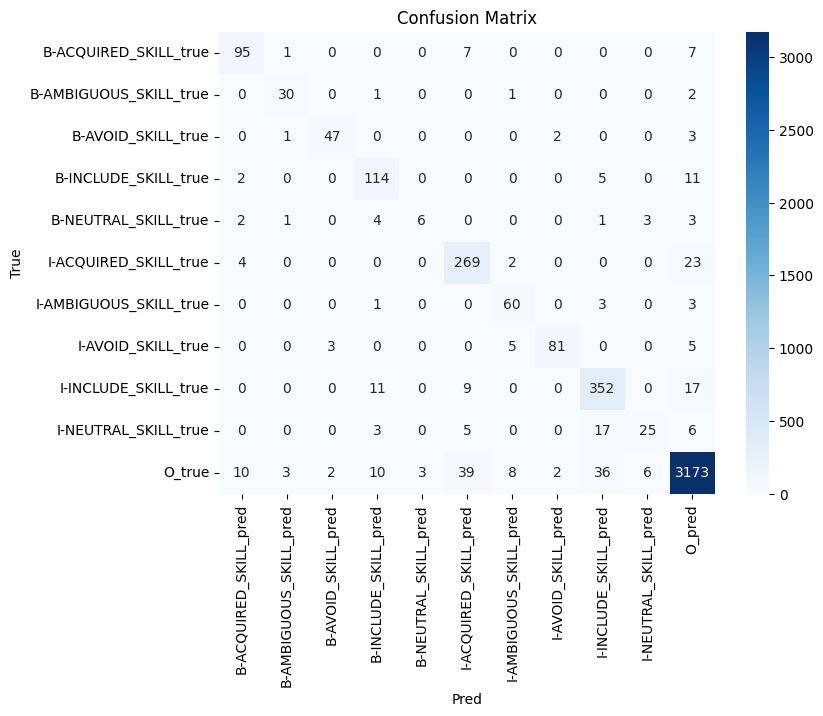

In [17]:
import itertools
from sklearn.metrics import confusion_matrix
import pandas as pd

# Flatten
y_true_flat = list(itertools.chain.from_iterable(y_true))
y_pred_flat = list(itertools.chain.from_iterable(y_pred))

def to_binary(label):
    # adattalo ai tuoi label (es. se hai "B-SKILL", "I-SKILL", ecc.)
    return "SKILL" if "SKILL" in label else "OTHER"

y_true_bin = [l for l in y_true_flat]
y_pred_bin = [l for l in y_pred_flat]

'''cm = confusion_matrix(y_true_bin, y_pred_bin, labels=["B-SKILL","I-SKILL", "O"])
df_cm = pd.DataFrame(cm, index=["B-SKILL_true", "I-SKILL_true", "O_true"],
                        columns=["B-SKILL_pred", "I-SKILL_pred", "O_pred"])
print(df_cm)'''

labels_cm = sorted(set(y_true_flat + y_pred_flat))
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels_cm)
df_cm = pd.DataFrame(cm, index=[f"{l}_true" for l in labels_cm],
                        columns=[f"{l}_pred" for l in labels_cm])

# Flatten
y_true_flat = list(itertools.chain.from_iterable(y_true))
y_pred_flat = list(itertools.chain.from_iterable(y_pred))

def to_binary(label):
    # adattalo ai tuoi label (es. se hai "B-SKILL", "I-SKILL", ecc.)
    return "SKILL" if "SKILL" in label else "OTHER"

y_true_bin = [l for l in y_true_flat]
y_pred_bin = [l for l in y_pred_flat]

'''cm = confusion_matrix(y_true_bin, y_pred_bin, labels=["B-SKILL","I-SKILL", "O"])
df_cm = pd.DataFrame(cm, index=["B-SKILL_true", "I-SKILL_true", "O_true"],
                        columns=["B-SKILL_pred", "I-SKILL_pred", "O_pred"])
print(df_cm)'''

labels_cm = sorted(set(y_true_flat + y_pred_flat))
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels_cm)
df_cm = pd.DataFrame(cm, index=[f"{l}_true" for l in labels_cm],
                        columns=[f"{l}_pred" for l in labels_cm])

plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Pred')
plt.show()


In [18]:
def print_pretty_errors(tokens, true_tags, pred_tags):
    print(f"{'Token':<20} | {'True':<15} | {'Pred':<15}")
    print("-" * 55)
    for t, tt, pt in zip(tokens, true_tags, pred_tags):
        marker = " <--- ERROR" if tt != pt else ""
        print(f"{t:<20} | {tt:<15} | {pt:<15} {marker}")

In [19]:

error_examples = []
for i, (tl, tp) in enumerate(zip(y_true, y_pred)):
    if tl != tp:  
        error_examples.append((i, tl, tp))

'''idx = error_examples[5][0]
print_pretty_errors(test_dataset[idx]["tokens"], y_true[idx], y_pred[idx])'''
        
for idx, tl, tp in error_examples[10:15]:
    print(f"\nExample {idx}")
    #print("TRUE: ", tl)
    #print("PRED: ", tp)
    print_pretty_errors(test_dataset[idx]["tokens"], y_true[idx], y_pred[idx])
    # print(test_dataset[idx]["tokens"]) 


Example 41
Token                | True            | Pred           
-------------------------------------------------------
I'm                  | O               | O               
moving               | O               | O               
into                 | O               | O               
library              | O               | O               
and                  | O               | O               
education            | O               | O               
services,            | O               | O               
and                  | O               | O               
I've                 | O               | O               
already              | O               | O               
consulted            | B-ACQUIRED_SKILL | B-ACQUIRED_SKILL 
different            | I-ACQUIRED_SKILL | I-ACQUIRED_SKILL 
information          | I-ACQUIRED_SKILL | I-ACQUIRED_SKILL 
sources              | I-ACQUIRED_SKILL | I-ACQUIRED_SKILL 
for                  | O               | I-ACQUIRED_SKI

In [20]:
def get_classification_errors(tokens, y_true, y_pred):
    errors = []
    for i in range(len(y_true)):
        # Filtriamo: cerchiamo dove entrambi hanno predetto una SKILL (non O) 
        # ma di tipo diverso (es. ACQUIRED vs INCLUDE)
        for t, gt, pt in zip(tokens[i], y_true[i], y_pred[i]):
            if gt != pt and gt != 'O' and pt != 'O':
                errors.append({
                    "sentence_idx": i,
                    "token": t,
                    "gold": gt,
                    "pred": pt,
                    "full_sentence": " ".join(tokens[i])
                })
                break 
    return errors

# Esempio d'uso
class_errors = get_classification_errors(test_dataset["tokens"], y_true, y_pred)
print(f"Trovati {len(class_errors)} errori di classificazione pura.")

Trovati 46 errori di classificazione pura.


In [21]:
for err in class_errors[:]:
    idx = err["sentence_idx"]
    print(f"--- ERRORE NELLA FRASE {idx} ---")
    print_pretty_errors(test_dataset[idx]["tokens"], y_true[idx], y_pred[idx])
    print("\n" + "="*60 + "\n")

--- ERRORE NELLA FRASE 11 ---
Token                | True            | Pred           
-------------------------------------------------------
I                    | O               | O               
am                   | O               | O               
good                 | O               | O               
at                   | O               | O               
collecting           | O               | B-ACQUIRED_SKILL  <--- ERROR
and                  | O               | I-ACQUIRED_SKILL  <--- ERROR
analysing            | B-ACQUIRED_SKILL | I-ACQUIRED_SKILL  <--- ERROR
data                 | I-ACQUIRED_SKILL | I-ACQUIRED_SKILL 
for                  | O               | I-ACQUIRED_SKILL  <--- ERROR
qualitative          | B-ACQUIRED_SKILL | I-ACQUIRED_SKILL  <--- ERROR
research.            | I-ACQUIRED_SKILL | I-ACQUIRED_SKILL 


--- ERRORE NELLA FRASE 21 ---
Token                | True            | Pred           
-------------------------------------------------------
I'm     

# TRY WITH DIFFERENT DATASET

In [29]:
with open('./train_datasets/training_data_bio_multi.json','r') as f:
    test_personalized = json.load(f)

data_personalized = {
    'tokens': [item[0] for item in test_personalized],
    'ner_tags_str': [item[1] for item in test_personalized] # Temporarily store tags as strings
}

# Create a Dataset object
raw_dataset_personalized = Dataset.from_dict(data_personalized)

tokenized_test_personalized = raw_dataset_personalized.map(tokenize_and_align_labels,
                                                           batched=True,
                                                           remove_columns=raw_dataset_personalized.column_names)
print(tokenized_test_personalized[:5])

Map: 100%|██████████| 556/556 [00:00<00:00, 13044.81 examples/s]

{'input_ids': [[0, 87, 26, 39, 47644, 1672, 45, 6496, 53894, 56, 3934, 19856, 2397, 4, 1284, 42551, 538, 87, 26, 71, 1884, 47, 71864, 313, 37223, 100, 5036, 6637, 442, 11405, 90, 163, 1810, 5, 2], [0, 984, 398, 5351, 442, 25, 7, 41965, 52080, 627, 100, 2053, 114137, 707, 5608, 87, 32153, 98, 31347, 214, 80866, 64457, 32, 2], [0, 87, 49782, 853, 47013, 353, 4935, 83, 80234, 4, 1284, 87, 21771, 3714, 36157, 3055, 32233, 5299, 5, 2], [0, 87, 13648, 3444, 47, 88898, 94217, 120332, 3299, 2069, 117934, 442, 144570, 5792, 5045, 175961, 291, 140363, 41637, 5, 2], [0, 87, 26, 39, 16031, 678, 627, 21828, 61687, 7, 1284, 7464, 3871, 47, 30698, 3642, 47, 4331, 6524, 11727, 2737, 866, 61903, 7, 155965, 5, 2]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [30]:
predictions, labels, _ = trainer.predict(tokenized_test_personalized)
predictions = np.argmax(predictions, axis=2)

y_true = [[id2label[l] for l in lab if l != -100] for lab in labels]
y_pred = [
    [id2label[p] for p, l in zip(pred, lab) if l != -100]
    for pred, lab in zip(predictions, labels)
]


In [31]:
print(classification_report(y_true=y_true, y_pred=y_pred))

                 precision    recall  f1-score   support

 ACQUIRED_SKILL       0.94      0.94      0.94       154
AMBIGUOUS_SKILL       0.00      0.00      0.00         0
    AVOID_SKILL       0.94      0.95      0.94       157
  INCLUDE_SKILL       0.89      0.89      0.89       502
  NEUTRAL_SKILL       0.91      0.91      0.91        89

      micro avg       0.91      0.91      0.91       902
      macro avg       0.74      0.74      0.74       902
   weighted avg       0.91      0.91      0.91       902



c:\Users\alexi\Desktop\rl_reccomender_course\.venv312\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [32]:
error_idxs = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]

for idx in error_idxs[:5]:   # mostra i primi 5
    print(f"\nExample {idx}")
    print_pretty_errors(
        raw_dataset_personalized[idx]["tokens"],
        y_true[idx],
        y_pred[idx]
    )


Example 2
Token                | True            | Pred           
-------------------------------------------------------
I                    | O               | O               
heard                | O               | O               
React                | B-INCLUDE_SKILL | B-INCLUDE_SKILL 
Native               | I-INCLUDE_SKILL | I-AMBIGUOUS_SKILL  <--- ERROR
is                   | O               | O               
useful,              | O               | O               
but                  | O               | O               
I                    | O               | O               
already              | O               | O               
know                 | O               | O               
Flutter              | B-ACQUIRED_SKILL | B-ACQUIRED_SKILL 
quite                | O               | O               
well.                | O               | O               

Example 13
Token                | True            | Pred           
--------------------------------------